# **Import Required Libraries**

In [ ]:
# ==========================================
# Import Required Libraries
# Employee Attrition Prediction - Novora
# ==========================================

# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)


# Handle warnings
import warnings
warnings.filterwarnings('ignore')


# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# Plot configuration
plt.style.use('default')

## **Load Both Datasets**

In [ ]:
# Load HR dataset
hr_data = pd.read_csv("/content/hr_op.csv")

# Load Personal dataset
personal_data = pd.read_excel("/content/personal_op.xlsx")

## **Check Dataset Dimensions**

In [ ]:
print("HR Dataset Shape:")
print(hr_data.shape)


print("\nPersonal Dataset Shape:")
print(personal_data.shape)

HR Dataset Shape:
(5000, 13)

Personal Dataset Shape:
(5000, 8)


# **Remove Duplicate Attrition Column Before Combining**

Because both datasets contain:




*   employee_id
*   attrition



Drop attrition from personal dataset.

In [ ]:
personal_data_clean = personal_data.drop(
    columns=['attrition']
)

# **Now, Merging both the datasets of Novora**

In [ ]:
# Merge datasets

Novora_employee_data = pd.merge(
    hr_data,
    personal_data_clean,
    on='employee_id',
    how='inner'
)


# Display combined dataset

Novora_employee_data.head()

,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition,age,gender,ethnicity,marital_status,disability_status,commute_distance_km
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0,34,Male,Other,Single,NaN,6.0
1,10002,Manager,Technology,8.04,3601.76,9.2,NaN,2,2,23,5,1,0,33,Female,Other,Widowed,NaN,21.7
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1,49,Male,White,Widowed,NaN,12.1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0,62,Male,Mixed,Married,NaN,18.4
4,10005,Developer,Operations,0.06,2791.37,17.2,NaN,1,2,30,1,0,1,21,Female,Asian,Married,NaN,5.6


## **Check Combined Dataset**

In [ ]:
Novora_employee_data.shape

(5000, 19)

## **Numerical Outlier Detection Using IQR**

## **Monthly Income**

In [ ]:
Q1 = Novora_employee_data['monthly_income'].quantile(0.25)

Q3 = Novora_employee_data['monthly_income'].quantile(0.75)

IQR = Q3-Q1


income_outliers = Novora_employee_data[
    (Novora_employee_data['monthly_income'] < Q1-1.5*IQR) |
    (Novora_employee_data['monthly_income'] > Q3+1.5*IQR)
]


print(
    "Income Outliers:",
    income_outliers.shape[0]
)

Income Outliers: 17


## **Overtime Outliers**

In [ ]:
Q1 = Novora_employee_data['overtime_hours'].quantile(0.25)

Q3 = Novora_employee_data['overtime_hours'].quantile(0.75)

IQR = Q3-Q1


overtime_outliers = Novora_employee_data[
    (Novora_employee_data['overtime_hours'] < Q1-1.5*IQR) |
    (Novora_employee_data['overtime_hours'] > Q3+1.5*IQR)
]


print(
    "Overtime Outliers:",
    overtime_outliers.shape[0]
)

Overtime Outliers: 140


# **Descriptive Statistics**

## **Distribution of Employees by Department**

In [ ]:
Novora_employee_data['department'] = Novora_employee_data['department'].replace({
    'C': 'Consulting',})

In [ ]:
department_count = Novora_employee_data['department'].value_counts()
department_count

,count
department,
Technology,1065
Operations,1004
Consulting,985
HR,973
Finance,973


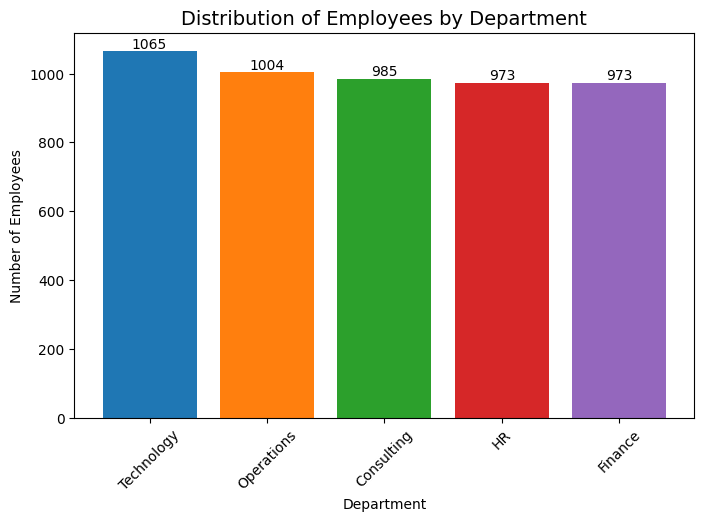

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    department_count.index,
    department_count.values,
    color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
)

plt.title(
    "Distribution of Employees by Department",
    fontsize=14
)

plt.xlabel("Department")

plt.ylabel("Number of Employees")


# Add data labels

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.xticks(rotation=45)

plt.show()

## **Distribution of Employees by Job Role**

In [ ]:
Novora_employee_data['job_role'] = Novora_employee_data['job_role'].replace({
    'F': 'Finance',})

In [ ]:
job_role_count = Novora_employee_data['job_role'].value_counts()

job_role_count

,count
job_role,
Manager,747
HR,738
Consultant,735
Finance,712
Analyst,694
Developer,691
Operations,683


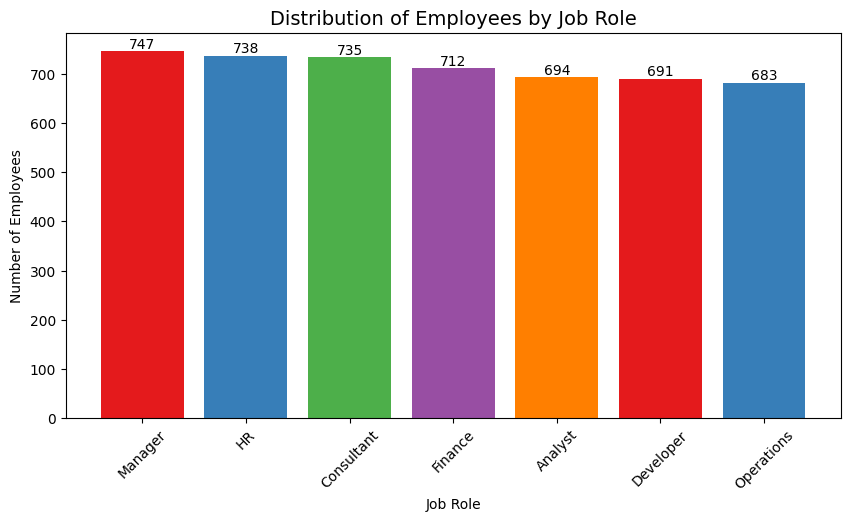

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    job_role_count.index,
    job_role_count.values,
    color=[
        '#e41a1c',
        '#377eb8',
        '#4daf4a',
        '#984ea3',
        '#ff7f00'
    ]
)


plt.title(
    "Distribution of Employees by Job Role",
    fontsize=14
)

plt.xlabel("Job Role")

plt.ylabel("Number of Employees")


for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.xticks(rotation=45)

plt.show()

## **Average Tenure Years of Employees**

In [ ]:
average_tenure = Novora_employee_data['tenure_years'].mean()

print(
    "Average Employee Tenure:",
    round(average_tenure,2),
    "years"
)

Average Employee Tenure: 2.91 years


## **Average Monthly Income by Department**

In [ ]:
income_department = (
    Novora_employee_data
    .groupby('department')['monthly_income']
    .mean()
    .sort_values()
)


income_department

,monthly_income
department,
Operations,3965.337022
Consulting,4016.294244
Finance,4018.479517
Technology,4029.323305
HR,4037.124635


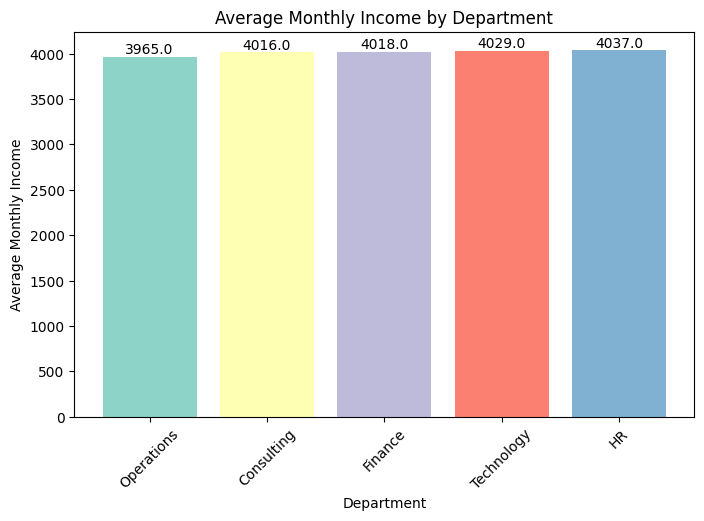

In [ ]:
plt.figure(figsize=(8,5))


bars = plt.bar(
    income_department.index,
    income_department.values,
    color=[
        '#8dd3c7',
        '#ffffb3',
        '#bebada',
        '#fb8072',
        '#80b1d3'
    ]
)


plt.title(
    "Average Monthly Income by Department"
)


plt.xlabel(
    "Department"
)


plt.ylabel(
    "Average Monthly Income"
)



for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),0),
        ha='center',
        va='bottom'
    )


plt.xticks(rotation=45)

plt.show()

## **Average Overtime Hours (Stayed vs Left Employees)**

In [ ]:
overtime_attrition = (
    Novora_employee_data
    .groupby('attrition')['overtime_hours']
    .mean()
)


overtime_attrition

,overtime_hours
attrition,
0,18.302275
1,22.560383


In [ ]:
overtime_attrition.index = [
    'Stayed',
    'Left'
]

overtime_attrition

,overtime_hours
Stayed,18.302275
Left,22.560383


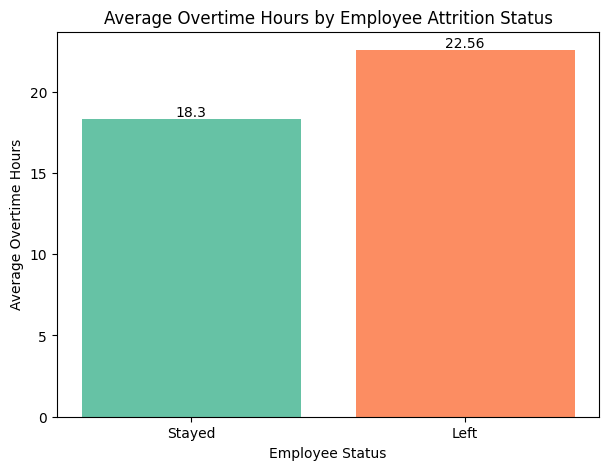

In [ ]:
plt.figure(figsize=(7,5))


bars = plt.bar(
    overtime_attrition.index,
    overtime_attrition.values,
    color=[
        '#66c2a5',
        '#fc8d62'
    ]
)


plt.title(
    "Average Overtime Hours by Employee Attrition Status"
)


plt.xlabel(
    "Employee Status"
)


plt.ylabel(
    "Average Overtime Hours"
)



for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha='center',
        va='bottom'
    )


plt.show()

## **Distribution of Monthly Income**

In [ ]:
Novora_employee_data['monthly_income'].describe()

,monthly_income
count,5000.000000
mean,4013.316072
std,1170.102395
min,1500.000000
25%,3207.612500
50%,4004.070000
75%,4794.770000
max,8114.690000


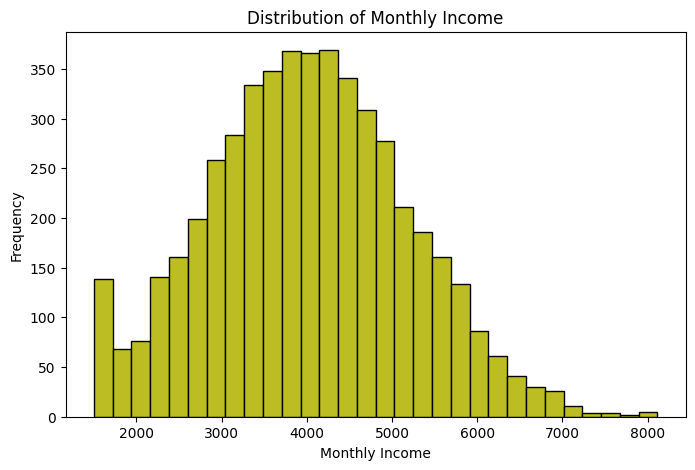

In [ ]:
plt.figure(figsize=(8,5))


plt.hist(
    Novora_employee_data['monthly_income'],
    bins=30,
    color='#bcbd22',
    edgecolor='black'
)


plt.title(
    "Distribution of Monthly Income"
)


plt.xlabel(
    "Monthly Income"
)


plt.ylabel(
    "Frequency"
)


plt.show()

## **Distribution of Ethnicity**

In [ ]:
Novora_employee_data['ethnicity'] = Novora_employee_data['ethnicity'].replace({
    'W': 'White',})

In [ ]:
ethnicity_count = (
    Novora_employee_data['ethnicity']
    .value_counts()
)


ethnicity_count

,count
ethnicity,
White,1049
Asian,1013
Other,998
Black,983
Mixed,957


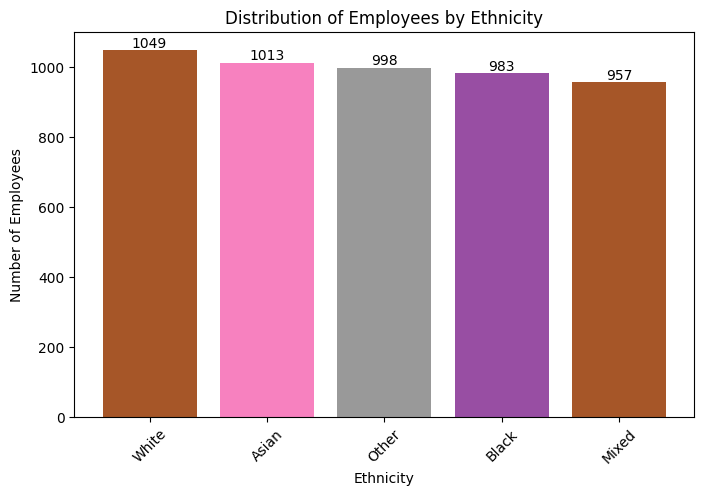

In [ ]:
plt.figure(figsize=(8,5))


bars = plt.bar(
    ethnicity_count.index,
    ethnicity_count.values,
    color=[
        '#a65628',
        '#f781bf',
        '#999999',
        '#984ea3'
    ]
)


plt.title(
    "Distribution of Employees by Ethnicity"
)


plt.xlabel(
    "Ethnicity"
)


plt.ylabel(
    "Number of Employees"
)



for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.xticks(rotation=45)

plt.show()

## **Average Monthly Income by Gender**

In [ ]:
Novora_employee_data['gender'] = Novora_employee_data['gender'].replace({
    'O': 'Other',})

In [ ]:
gender_income = (
    Novora_employee_data
    .groupby('gender')['monthly_income']
    .mean()
)


gender_income

,monthly_income
gender,
Female,3982.139554
Male,4062.380084
Other,3995.269847


## **Marital Status Distribution**

In [ ]:
Novora_employee_data['marital_status'] = Novora_employee_data['marital_status'].replace({
    'S': 'Single','W':'Widowed'})

In [ ]:
marital_distribution = (
    Novora_employee_data['marital_status']
    .value_counts()
)


marital_distribution

,count
marital_status,
Single,1299
Married,1258
Widowed,1239
Divorced,1204


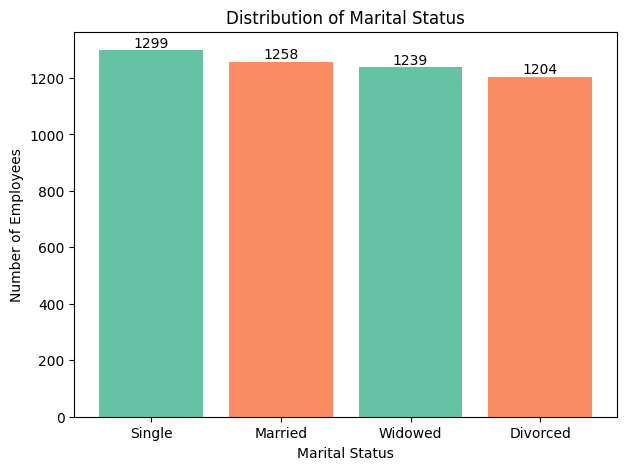

In [ ]:
plt.figure(figsize=(7,5))


bars = plt.bar(
    marital_distribution.index,
    marital_distribution.values,
    color=[
        '#66c2a5',
        '#fc8d62'
    ]
)


plt.title(
    "Distribution of Marital Status"
)


plt.xlabel(
    "Marital Status"
)


plt.ylabel(
    "Number of Employees"
)



for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.show()

## **Disability Status Distribution**

In [ ]:
disability_distribution = (
    Novora_employee_data['disability_status']
    .value_counts()
)


disability_distribution

,count
disability_status,
Mental,353
Physical,266
Other,139
0,2


## **Relationship Between Overtime, Income and Work-Life Balance**

In [ ]:
relationship_data = Novora_employee_data[
[
'overtime_hours',
'monthly_income',
'work_life_balance_score'
]
]


relationship_data.corr()

,overtime_hours,monthly_income,work_life_balance_score
overtime_hours,1.000000,-0.006073,-0.005019
monthly_income,-0.006073,1.000000,0.008140
work_life_balance_score,-0.005019,0.008140,1.000000


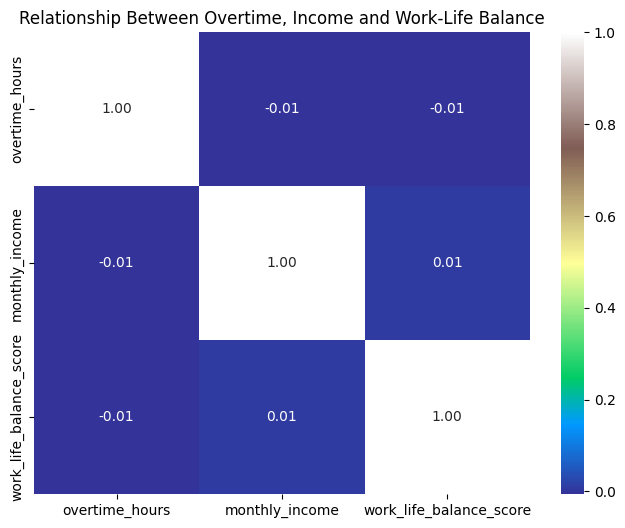

In [ ]:
plt.figure(figsize=(8,6))


sns.heatmap(
    relationship_data.corr(),
    annot=True,
    cmap='terrain',
    fmt=".2f"
)


plt.title(
    "Relationship Between Overtime, Income and Work-Life Balance"
)


plt.show()

# **Data Preparation for Modelling**

In [ ]:
model_data = Novora_employee_data.drop(
    columns=['employee_id']
)

## **Separate Features and Target Variable**

In [ ]:
# Independent variables
X = model_data.drop(
    columns=['attrition']
)

# Target variable
y = model_data['attrition']

## **Identify Categorical and Numerical Columns**

In [ ]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns


numerical_columns = X.select_dtypes(
    exclude=['object']
).columns

## **Encode Categorical Variables**

In [ ]:
encoder = LabelEncoder()


for col in categorical_columns:
    # Convert all values to string type and fill NaN values with 'Unknown'
    X[col] = X[col].astype(str).fillna('Unknown')
    X[col] = encoder.fit_transform(
        X[col]
    )

## **Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    X
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

## **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

# **RANDOM FOREST MODEL**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)


rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:
rf_prediction = rf_model.predict(
    X_test
)
rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


print(
    "Random Forest Accuracy:",
    round(rf_accuracy,4)
)

Random Forest Accuracy: 0.6


In [ ]:
print(
    "Random Forest Classification Report"
)


print(
    classification_report(
        y_test,
        rf_prediction
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.64      0.70      0.66       571
           1       0.54      0.47      0.50       429

    accuracy                           0.60      1000
   macro avg       0.59      0.58      0.58      1000
weighted avg       0.59      0.60      0.60      1000



In [ ]:
rf_logloss = log_loss(
    y_test,
    rf_model.predict_proba(X_test)
)


print(
    "Random Forest Log Loss:",
    round(rf_logloss,4)
)

Random Forest Log Loss: 0.6611


In [ ]:
rf_cm = confusion_matrix(
    y_test,
    rf_prediction
)

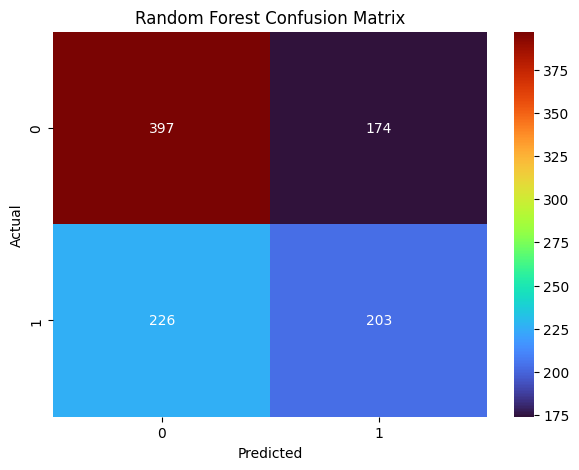

In [ ]:
plt.figure(figsize=(7,5))


sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='turbo'
)


plt.title(
    "Random Forest Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

In [ ]:
rf_auc = roc_auc_score(
    y_test,
    rf_probability
)


print(
    "Random Forest ROC-AUC:",
    round(rf_auc,4)
)

Random Forest ROC-AUC: 0.6293


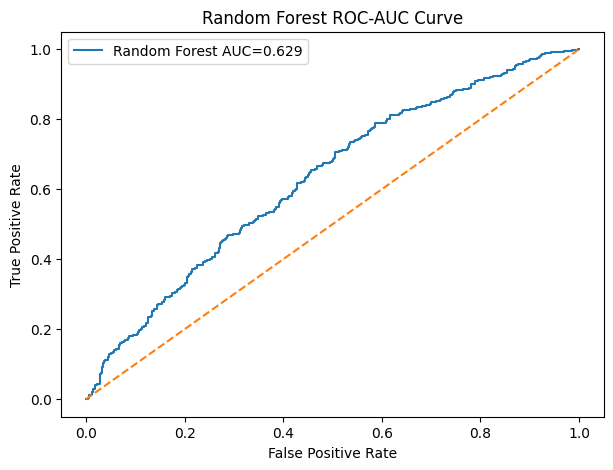

In [ ]:
rf_fpr, rf_tpr, rf_threshold = roc_curve(
    y_test,
    rf_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC={rf_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)


plt.title(
    "Random Forest ROC-AUC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.show()

# **XGBOOST MODEL**

In [ ]:
xgb_model = XGBClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=5,

    random_state=42,

    eval_metric='logloss'

)


xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_prediction = xgb_model.predict(
    X_test
)
xgb_probability = xgb_model.predict_proba(
    X_test
)[:,1]

In [ ]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)


print(
    "XGBoost Accuracy:",
    round(xgb_accuracy,4)
)

XGBoost Accuracy: 0.588


In [ ]:
print(
    "XGBoost Classification Report"
)


print(
    classification_report(
        y_test,
        xgb_prediction
    )
)

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       571
           1       0.53      0.40      0.46       429

    accuracy                           0.59      1000
   macro avg       0.57      0.57      0.56      1000
weighted avg       0.58      0.59      0.58      1000



In [ ]:
xgb_logloss = log_loss(
    y_test,
    xgb_model.predict_proba(X_test)
)


print(
    "XGBoost Log Loss:",
    round(xgb_logloss,4)
)

XGBoost Log Loss: 0.6804


In [ ]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_prediction
)

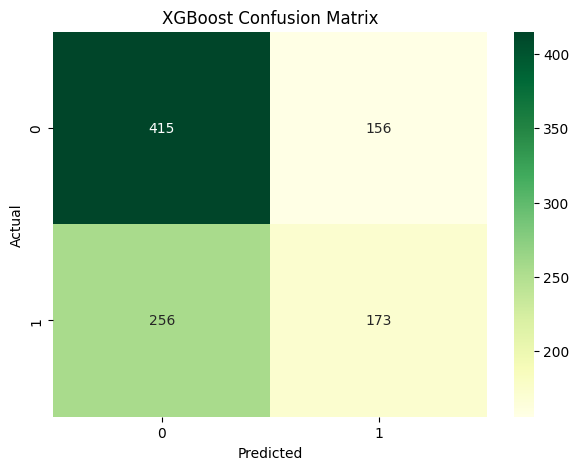

In [ ]:
plt.figure(figsize=(7,5))


sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='YlGn'
)


plt.title(
    "XGBoost Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

In [ ]:
xgb_auc = roc_auc_score(
    y_test,
    xgb_probability
)


print(
    "XGBoost ROC-AUC:",
    round(xgb_auc,4)
)

XGBoost ROC-AUC: 0.6061


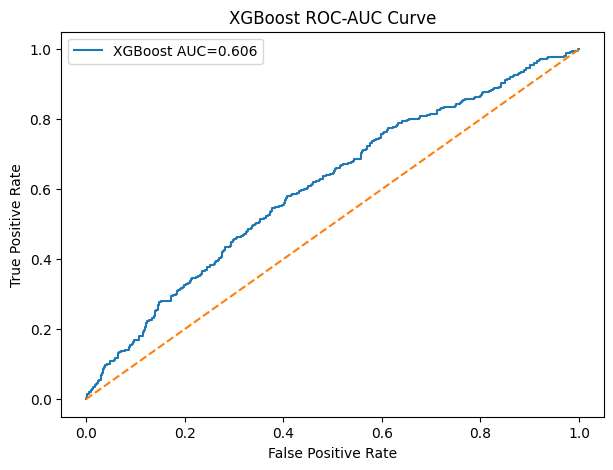

In [ ]:
xgb_fpr, xgb_tpr, xgb_threshold = roc_curve(
    y_test,
    xgb_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost AUC={xgb_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)



plt.title(
    "XGBoost ROC-AUC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.show()